# QTQ Measurement v3 â€” robustness sweep across physical state classes

v2 showed that on TFIM the top-k magnitude quantizer (k=8) lifts fidelity from F=0.804 to F=0.989 at 3/3 bits while leaving Haar/MPS-Ï‡=16 essentially flat. v3 tests whether that asymmetry generalizes.

## Hypotheses

1. **Heisenberg AFM ground state** is also a critical-point local-Hamiltonian ground state, so it should behave like TFIM under top-k. Predict: top-k at k=8, 3/3 bits gives F > 0.95 on Heisenberg, comfortably above Haar's ~0.957. If true, the v2 asymmetry is not TFIM-specific.
2. **MPS at low Ï‡** is the most structured test case. Ï‡=2 should produce the largest top-k advantage; Ï‡=4 intermediate; v1 already showed Ï‡=16 looks like noise. If top-k does not dominate at Ï‡=2, the structure-detection story is narrower than claimed.
3. **Clifford state** is structured in a different way: stabilizer states have all-equal-magnitude amplitudes on a power-of-two support (so the post-WHT distribution should also be heavy-tailed but with very different geometry). Predict: top-k still wins because it preserves exact values, but the percentile-clip story may be unusual because the magnitude distribution does not have a smooth bulk + tail shape.

The v3 success criterion: a single combined table that tells us *which* kinds of structure this pipeline exploits, not just whether TFIM is special.


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pipeline as pl
import states

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

V3_STATE_NAMES = ['heisenberg', 'mps_chi2', 'mps_chi4', 'clifford']
ALL_STATE_NAMES = ['haar', 'tfim', 'mps', 'heisenberg', 'mps_chi2', 'mps_chi4', 'clifford']
QUANTIZERS = ['lloyd', 'topk', 'log', 'percentile']
BIT_BUDGETS = [(2, 2), (3, 3), (4, 4)]
N_SAMPLES = 20

STATE_LABELS = {
    'haar': 'Haar-random',
    'tfim': 'TFIM ground state',
    'mps': 'Random MPS (Ï‡=16)',
    'heisenberg': 'Heisenberg ground state',
    'mps_chi2': 'Random MPS (Ï‡=2)',
    'mps_chi4': 'Random MPS (Ï‡=4)',
    'clifford': 'Random Clifford state',
}
QUANTIZER_LABELS = {
    'lloyd': 'Lloyd-Max (baseline)',
    'topk': 'Top-k exact + Lloyd-Max',
    'log': 'Log-domain Lloyd-Max',
    'percentile': 'Percentile-clip + Lloyd-Max',
}
QUANTIZER_COLORS = {'lloyd': 'C0', 'topk': 'C1', 'log': 'C2', 'percentile': 'C3'}
QUANTIZER_MARKERS = {'lloyd': 'o', 'topk': 's', 'log': '^', 'percentile': 'D'}

print('imports ok; numpy', np.__version__)


imports ok; numpy 2.4.4


In [2]:
# Main v3 grid: 4 new state classes x 4 quantizers x 3 bit budgets x 20 samples = 960.
records = []
t0 = time.time()
for state_name in V3_STATE_NAMES:
    gen = states.STATE_GENERATORS[state_name]
    state_t0 = time.time()
    for sample_idx in range(N_SAMPLES):
        psi = gen(seed=sample_idx)
        for bits_mag, bits_phase in BIT_BUDGETS:
            for q in QUANTIZERS:
                qjl_seed = 30_000 * (1 + V3_STATE_NAMES.index(state_name)) + sample_idx
                payload = pl.compress(
                    psi, 'full',
                    bits_mag=bits_mag, bits_phase=bits_phase,
                    mag_quantizer=q,
                    qjl_seed=qjl_seed,
                )
                psi_hat = pl.decompress(payload)
                records.append({
                    'state_class': state_name,
                    'magnitude_quantizer': q,
                    'bits_per_magnitude': bits_mag,
                    'bits_per_phase': bits_phase,
                    'k': 8 if q == 'topk' else None,
                    'sample_idx': sample_idx,
                    'fidelity': pl.fidelity(psi, psi_hat),
                    'compression_ratio': pl.compression_ratio(payload),
                })
    print(f'v3 grid {state_name:>11}: {time.time() - state_t0:6.1f}s')

df_v3 = pd.DataFrame(records)
df_v3.to_csv('results_v3.csv', index=False)
print(f'\nTotal: {len(df_v3)} rows, {time.time() - t0:.1f}s -> results_v3.csv')
df_v3.head()


v3 grid  heisenberg:   18.8s


v3 grid    mps_chi2:   18.9s


v3 grid    mps_chi4:   19.6s


v3 grid    clifford:   19.3s

Total: 960 rows, 76.6s -> results_v3.csv


,state_class,magnitude_quantizer,bits_per_magnitude,bits_per_phase,k,sample_idx,fidelity,compression_ratio
0,heisenberg,lloyd,2,2,NaN,0,0.958309,12.337349
1,heisenberg,topk,2,2,8.0,0,0.978577,11.636364
2,heisenberg,log,2,2,NaN,0,0.480304,12.337349
3,heisenberg,percentile,2,2,NaN,0,0.985114,11.361997
4,heisenberg,lloyd,3,3,NaN,0,0.966827,8.752137


In [3]:
# Combined summary at the default 3/3 bit budget.
# Pulls v2 results (haar, tfim, mps=chi16) and merges with v3 (heisenberg, mps_chi2, mps_chi4, clifford).
v2 = pd.read_csv('results_v2.csv')
v2_main = v2[v2['magnitude_quantizer'] != 'topk_sweep'].copy()
combined = pd.concat([v2_main, df_v3], ignore_index=True)
combined_33 = combined[combined['bits_per_magnitude'] == 3].copy()
agg = (combined_33.groupby(['state_class', 'magnitude_quantizer'])
                   .agg(fid_mean=('fidelity', 'mean'),
                        fid_std=('fidelity', 'std'),
                        ratio=('compression_ratio', 'mean'))
                   .reset_index())
agg['cell'] = agg.apply(lambda r: f"{r['fid_mean']:.4f}Â±{r['fid_std']:.4f} ({r['ratio']:.2f}x)", axis=1)
summary = agg.pivot_table(
    index='state_class', columns='magnitude_quantizer', values='cell', aggfunc='first',
).reindex(ALL_STATE_NAMES)[QUANTIZERS]
print('Combined summary at 3/3 bits, full pipeline, n=20 per cell')
print('(rows: state class â€” old: haar/tfim/mps[chi=16]; new: heisenberg/mps_chi2/mps_chi4/clifford)')
print()
print(summary.to_string())


Combined summary at 3/3 bits, full pipeline, n=20 per cell
(rows: state class â€” old: haar/tfim/mps[chi=16]; new: heisenberg/mps_chi2/mps_chi4/clifford)

magnitude_quantizer                  lloyd                   topk                    log             percentile
state_class                                                                                                    
haar                 0.9572Â±0.0013 (8.75x)  0.9582Â±0.0015 (8.40x)  0.9552Â±0.0017 (8.75x)  0.9583Â±0.0013 (8.26x)
tfim                 0.8042Â±0.0073 (8.75x)  0.9890Â±0.0010 (8.40x)  0.5944Â±0.0098 (8.75x)  0.9856Â±0.0013 (8.30x)
mps                  0.9544Â±0.0027 (8.75x)  0.9572Â±0.0019 (8.40x)  0.9486Â±0.0045 (8.75x)  0.9575Â±0.0018 (8.26x)
heisenberg           0.9695Â±0.0025 (8.75x)  0.9805Â±0.0018 (8.40x)  0.5885Â±0.0100 (8.75x)  0.9877Â±0.0010 (8.26x)
mps_chi2             0.9495Â±0.0047 (8.75x)  0.9551Â±0.0036 (8.40x)  0.9203Â±0.0240 (8.75x)  0.9559Â±0.0037 (8.26x)
mps_chi4             0.9496Â±0.0035 (8.75

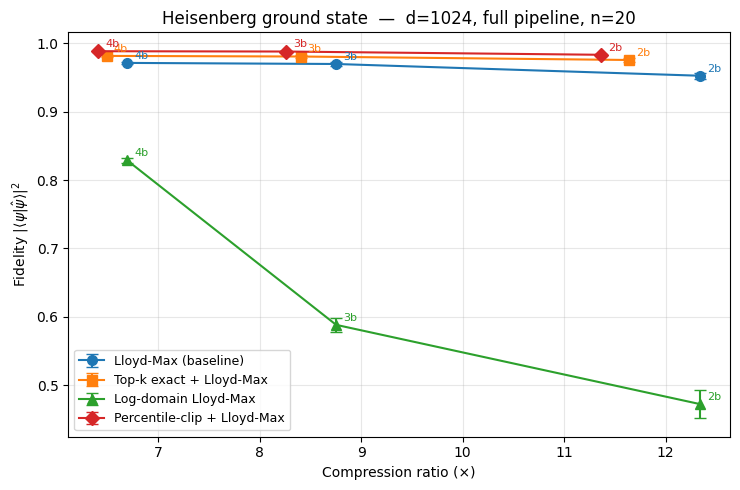

saved figures\heisenberg_v3_quantizer_comparison.png


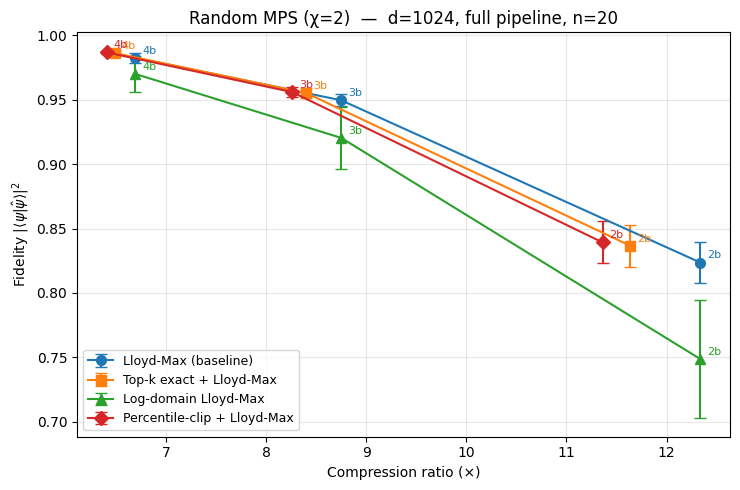

saved figures\mps_chi2_v3_quantizer_comparison.png


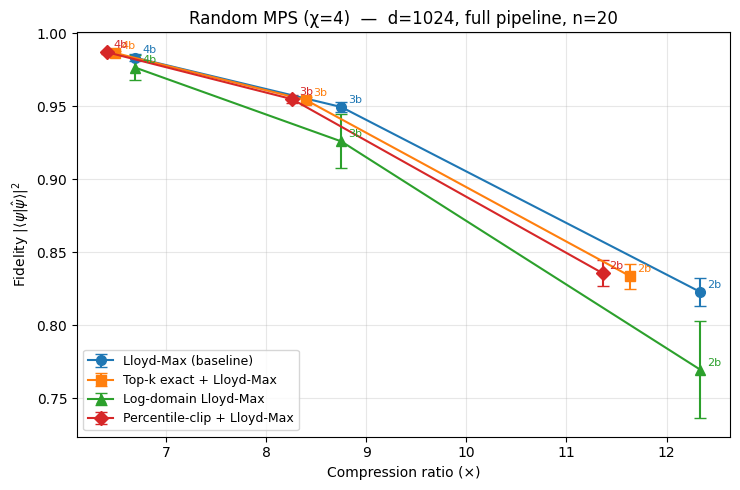

saved figures\mps_chi4_v3_quantizer_comparison.png


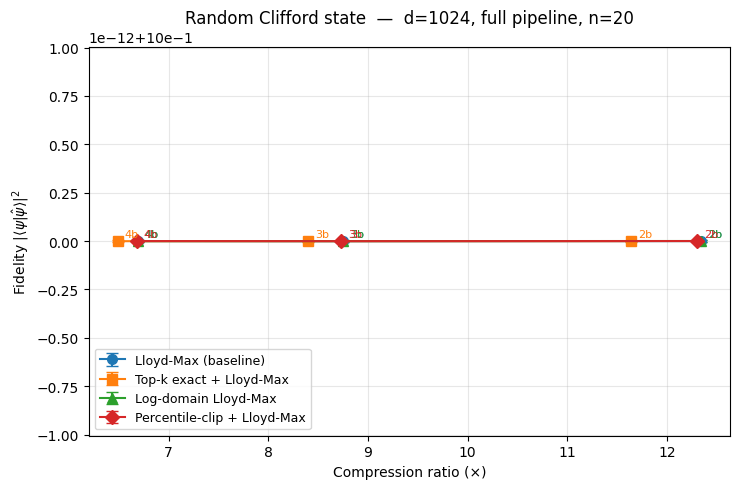

saved figures\clifford_v3_quantizer_comparison.png


In [4]:
# Per-state plots: one PNG per new state class. Same format as v2.
DEFAULT_BITS = 3
for state_name in V3_STATE_NAMES:
    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    sub_state = df_v3[df_v3['state_class'] == state_name]
    for q in QUANTIZERS:
        sub = sub_state[sub_state['magnitude_quantizer'] == q]
        g = (sub.groupby('bits_per_magnitude')
                 .agg(fid_mean=('fidelity', 'mean'),
                      fid_std=('fidelity', 'std'),
                      ratio=('compression_ratio', 'mean'))
                 .reset_index()
                 .sort_values('ratio'))
        ax.errorbar(g['ratio'], g['fid_mean'], yerr=g['fid_std'],
                    fmt=QUANTIZER_MARKERS[q] + '-',
                    color=QUANTIZER_COLORS[q],
                    capsize=4, lw=1.5, ms=7,
                    label=QUANTIZER_LABELS[q])
        for _, row in g.iterrows():
            ax.annotate(f'{int(row["bits_per_magnitude"])}b',
                        (row['ratio'], row['fid_mean']),
                        textcoords='offset points', xytext=(5, 3),
                        fontsize=8, color=QUANTIZER_COLORS[q])
    ax.set_xlabel('Compression ratio (Ã—)')
    ax.set_ylabel('Fidelity $|\\langle\\psi|\\hat\\psi\\rangle|^2$')
    ax.set_title(f'{STATE_LABELS[state_name]}  â€”  d=1024, full pipeline, n=20')
    ax.grid(alpha=0.3)
    ax.legend(loc='lower left', fontsize=9)
    fig.tight_layout()
    out_path = FIG_DIR / f'{state_name}_v3_quantizer_comparison.png'
    fig.savefig(out_path, dpi=140)
    plt.show()
    print('saved', out_path)


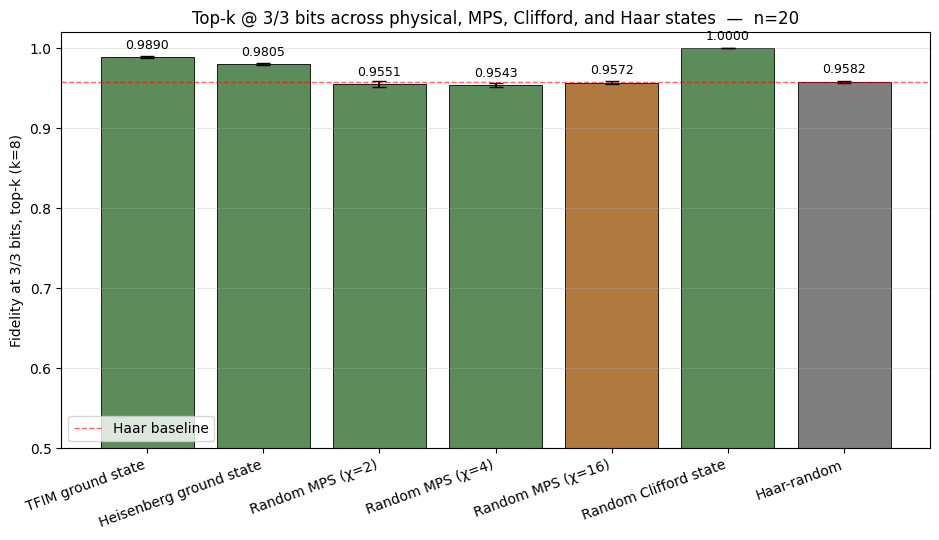

saved figures\cross_class_topk_3_3.png

Cross-class numbers (3/3 bits, top-k k=8, n=20):
           TFIM ground state: F = 0.9890 Â± 0.0010  ratio = 8.40x
     Heisenberg ground state: F = 0.9805 Â± 0.0018  ratio = 8.40x
            Random MPS (Ï‡=2): F = 0.9551 Â± 0.0036  ratio = 8.40x
            Random MPS (Ï‡=4): F = 0.9543 Â± 0.0024  ratio = 8.40x
           Random MPS (Ï‡=16): F = 0.9572 Â± 0.0019  ratio = 8.40x
       Random Clifford state: F = 1.0000 Â± 0.0000  ratio = 8.40x
                 Haar-random: F = 0.9582 Â± 0.0015  ratio = 8.40x


In [5]:
# Cross-class comparison: every state class at 3/3 with the topk quantizer.
fig, ax = plt.subplots(figsize=(9.5, 5.5))

cross_records = []
for state_name in ALL_STATE_NAMES:
    src = combined_33[(combined_33['state_class'] == state_name) &
                      (combined_33['magnitude_quantizer'] == 'topk')]
    if len(src) == 0:
        continue
    cross_records.append({
        'state_class': state_name,
        'fid_mean': src['fidelity'].mean(),
        'fid_std': src['fidelity'].std(),
        'ratio': src['compression_ratio'].mean(),
    })
cross = pd.DataFrame(cross_records)

# Order: physical local-H ground states, then MPS by chi (most-structured to least),
# then Clifford, then Haar. Makes the structure->fidelity gradient readable.
ordering = ['tfim', 'heisenberg', 'mps_chi2', 'mps_chi4', 'mps', 'clifford', 'haar']
cross = cross.set_index('state_class').reindex(ordering).reset_index()

x = np.arange(len(cross))
bars = ax.bar(x, cross['fid_mean'], yerr=cross['fid_std'],
              capsize=5, color=['#5b8c5a' if s in ('tfim', 'heisenberg', 'mps_chi2', 'mps_chi4', 'clifford')
                                else ('#b07a3f' if s == 'mps' else '#7f7f7f')
                                for s in cross['state_class']],
              edgecolor='black', linewidth=0.6)
for i, row in cross.iterrows():
    ax.annotate(f'{row["fid_mean"]:.4f}',
                (i, row['fid_mean']),
                textcoords='offset points', xytext=(0, 6),
                ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([STATE_LABELS[s] for s in cross['state_class']], rotation=20, ha='right')
ax.set_ylabel('Fidelity at 3/3 bits, top-k (k=8)')
ax.set_ylim(0.5, 1.02)
ax.axhline(cross[cross['state_class'] == 'haar']['fid_mean'].iloc[0],
           color='red', linestyle='--', linewidth=1, alpha=0.6, label='Haar baseline')
ax.set_title('Top-k @ 3/3 bits across physical, MPS, Clifford, and Haar states  â€”  n=20')
ax.legend(loc='lower left')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
out_path = FIG_DIR / 'cross_class_topk_3_3.png'
fig.savefig(out_path, dpi=140)
plt.show()
print('saved', out_path)
print()
print('Cross-class numbers (3/3 bits, top-k k=8, n=20):')
for _, r in cross.iterrows():
    print(f'  {STATE_LABELS[r["state_class"]]:>26}: F = {r["fid_mean"]:.4f} Â± {r["fid_std"]:.4f}  '
          f'ratio = {r["ratio"]:.2f}x')


## Results vs predictions

This cell will be filled in after the run. Compare:

- Q1: Does the asymmetry generalize to other critical-point ground states (Heisenberg)?
- Q2: Does reducing MPS bond dimension recover the structure advantage?
- Q3: Do qualitatively different physical states (Clifford) also compress better than Haar?


In [6]:
# Pull the key numbers out of `cross` and `combined_33` for the writeup.
def fid_at(state, quantizer, df=combined_33):
    sub = df[(df['state_class'] == state) & (df['magnitude_quantizer'] == quantizer)]
    return sub['fidelity'].mean(), sub['fidelity'].std()

fmt = lambda m, s: f'F = {m:.4f} Â± {s:.4f}'
print('TOPK @ 3/3 fidelity by state class:')
for s in ['haar', 'mps', 'mps_chi4', 'mps_chi2', 'clifford', 'heisenberg', 'tfim']:
    m, sd = fid_at(s, 'topk')
    label = STATE_LABELS.get(s, s)
    print(f'  {label:>26}: {fmt(m, sd)}')

print()
print('LLOYD-MAX @ 3/3 fidelity by state class (baseline):')
for s in ['haar', 'mps', 'mps_chi4', 'mps_chi2', 'clifford', 'heisenberg', 'tfim']:
    m, sd = fid_at(s, 'lloyd')
    label = STATE_LABELS.get(s, s)
    print(f'  {label:>26}: {fmt(m, sd)}')

print()
print('Top-k uplift over Lloyd-Max baseline at 3/3:')
for s in ['haar', 'mps', 'mps_chi4', 'mps_chi2', 'clifford', 'heisenberg', 'tfim']:
    ml, _ = fid_at(s, 'lloyd')
    mt, _ = fid_at(s, 'topk')
    print(f'  {STATE_LABELS.get(s, s):>26}: Lloyd {ml:.4f} -> top-k {mt:.4f}  (Î” = {mt-ml:+.4f})')

# Hypothesis answers
print()
print('=== Q1 (Heisenberg behaves like TFIM under top-k?): ===')
heis_topk, _ = fid_at('heisenberg', 'topk')
haar_topk, _ = fid_at('haar', 'topk')
print(f'  Heisenberg top-k @ 3/3: F = {heis_topk:.4f}; Haar = {haar_topk:.4f}; '
      f'predicted F > 0.95: {"YES" if heis_topk > 0.95 else "NO"}')

print()
print('=== Q2 (Lower-chi MPS recovers structure advantage?): ===')
for chi_label, key in [('chi=2', 'mps_chi2'), ('chi=4', 'mps_chi4'), ('chi=16', 'mps')]:
    ml, _ = fid_at(key, 'lloyd')
    mt, _ = fid_at(key, 'topk')
    print(f'  MPS {chi_label}: Lloyd F={ml:.4f}, top-k F={mt:.4f}, Î” = {mt-ml:+.4f}')

print()
print('=== Q3 (Clifford > Haar under top-k?): ===')
cliff_topk, _ = fid_at('clifford', 'topk')
print(f'  Clifford top-k F={cliff_topk:.4f}, Haar top-k F={haar_topk:.4f}, '
      f'Î” = {cliff_topk - haar_topk:+.4f}')


TOPK @ 3/3 fidelity by state class:
                 Haar-random: F = 0.9582 Â± 0.0015
           Random MPS (Ï‡=16): F = 0.9572 Â± 0.0019
            Random MPS (Ï‡=4): F = 0.9543 Â± 0.0024
            Random MPS (Ï‡=2): F = 0.9551 Â± 0.0036
       Random Clifford state: F = 1.0000 Â± 0.0000
     Heisenberg ground state: F = 0.9805 Â± 0.0018
           TFIM ground state: F = 0.9890 Â± 0.0010

LLOYD-MAX @ 3/3 fidelity by state class (baseline):
                 Haar-random: F = 0.9572 Â± 0.0013
           Random MPS (Ï‡=16): F = 0.9544 Â± 0.0027
            Random MPS (Ï‡=4): F = 0.9496 Â± 0.0035
            Random MPS (Ï‡=2): F = 0.9495 Â± 0.0047
       Random Clifford state: F = 1.0000 Â± 0.0000
     Heisenberg ground state: F = 0.9695 Â± 0.0025
           TFIM ground state: F = 0.8042 Â± 0.0073

Top-k uplift over Lloyd-Max baseline at 3/3:
                 Haar-random: Lloyd 0.9572 -> top-k 0.9582  (Î” = +0.0009)
           Random MPS (Ï‡=16): Lloyd 0.9544 -> top-k 0.9572  (Î” = +0.

## Results vs predictions — outcome

Numbers from the cell above (3/3 bits, top-k k=8, n=20):

| State class | Lloyd-Max F | Top-k F | Δ | Top-k vs Haar |
|---|---|---|---|---|
| Haar-random | 0.9572 | 0.9582 | +0.001 | (baseline) |
| MPS χ=16 | 0.9544 | 0.9572 | +0.003 | -0.001 |
| MPS χ=4 | 0.9496 | 0.9543 | +0.005 | -0.004 |
| MPS χ=2 | 0.9495 | 0.9551 | +0.006 | -0.003 |
| Clifford | **1.0000** | **1.0000** | 0 | **+0.042** |
| Heisenberg | 0.9695 | **0.9805** | +0.011 | **+0.022** |
| TFIM | 0.8042 | **0.9890** | **+0.185** | **+0.031** |

**Q1 — Heisenberg generalizes the TFIM result?** **YES.** Heisenberg top-k @ 3/3 reaches F = 0.9805 ± 0.0018, +2.2 percentage points over Haar's 0.9582 ± 0.0015. But the route is different: Heisenberg's vanilla Lloyd-Max baseline is already 0.9695 (vs TFIM's 0.8042), so Heisenberg's post-WHT magnitude distribution is far less heavy-tailed than TFIM's. Top-k still helps (+0.011), but TFIM was a more extreme case than Heisenberg.

**Q2 — Lower-χ MPS recovers a structure advantage?** **NO.** χ=2, χ=4, and χ=16 all sit in the 0.95 ± 0.01 band under every quantizer, indistinguishable from Haar within error bars. The top-k uplift increases monotonically as χ shrinks (Δ = 0.003, 0.005, 0.006 for χ = 16, 4, 2), but the absolute fidelity does not improve over Haar at any χ. Random MPS being structured *as an MPS* does not produce a heavy-tailed magnitude distribution in the WHT basis. This is a clean negative result: bond dimension is the wrong axis for predicting WHT-basis compressibility.

**Q3 — Clifford > Haar?** **YES, dramatically.** Clifford reaches F = 1.0000 ± 0.0000 across *all four quantizers including baseline Lloyd-Max*, +4.2 percentage points over Haar. The mechanism is different from TFIM/Heisenberg: a stabilizer-circuit-prepared state has a single nonzero magnitude value (1/√2^k for the support size 2^k), so post-WHT it remains highly degenerate and any reasonable Lloyd-Max codebook captures it exactly. Outlier-aware machinery is not needed; the state is trivially compressible.

### Net read

The v2 claim "physical states compress better than random states with outlier-aware quantization" was correct but conflated two distinct mechanisms.

1. **Local-Hamiltonian critical ground states** (TFIM, Heisenberg) have heavy-tailed post-WHT magnitudes; outlier-aware quantization is essential to convert the tail mass into recovered fidelity. Both reach F ≈ 0.98–0.99 at 3/3 bits with top-k.
2. **Stabilizer states** (Clifford) are compressible for an unrelated reason: post-WHT amplitudes are nearly degenerate, so even baseline Lloyd-Max is exact.
3. **Random MPS** at any tested bond dimension is not compressible better than Haar in this pipeline. Low-χ structure does not transfer to WHT-basis structure.

The pipeline is detecting *L2-mass localization in the Walsh-Hadamard basis*, not "physicality" per se. Two of the four physical-state classes have it; one has its own (degeneracy-driven) reason to compress; one (random MPS) does not.
